# Customer Churn Prediction Using Machine Learning

**Author:** Pentakota Manideep Jagannath

## Project Overview

This project develops a machine learning workflow to identify customers at higher risk of churn using customer demographic and engagement data.

## Problem Statement

The objective of this project is to analyze customer data and identify the factors that influence customer churn. The project aims to build a machine learning classification model that can predict whether a customer is likely to churn, helping telecom companies take proactive measures to improve customer retention.

## Data Source

The customer churn dataset was extracted from a MySQL database using SQL queries in MySQL Workbench and exported as a CSV file.

The final dataset used for analysis is `telecom_churn_final.csv`, containing 243,553 customer records and 14 features.

The dataset includes customer demographics, telecom partner information, location, registration details, and customer engagement indicators such as calls made, SMS sent, and data usage.

## Importing Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv("telecom_churn_final.csv")

## Dataset Overview

In [158]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,0,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,0
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [159]:
df.shape

(243553, 14)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [161]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.120122,24.015754,5001.354802,0.200002
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.260198,14.611419,2927.420055,0.400002
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,0.000000,0.000000,0.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [162]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

## Missing Values Analysis

In [163]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [164]:
df.isnull().sum().sum()

np.int64(0)

## Duplicate Records Analysis

In [165]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

In [166]:
df.columns.tolist()

['customer_id',
 'telecom_partner',
 'gender',
 'age',
 'state',
 'city',
 'pincode',
 'date_of_registration',
 'num_dependents',
 'estimated_salary',
 'calls_made',
 'sms_sent',
 'data_used',
 'churn']

In [167]:
df['churn'].value_counts()

churn
0    194842
1     48711
Name: count, dtype: int64

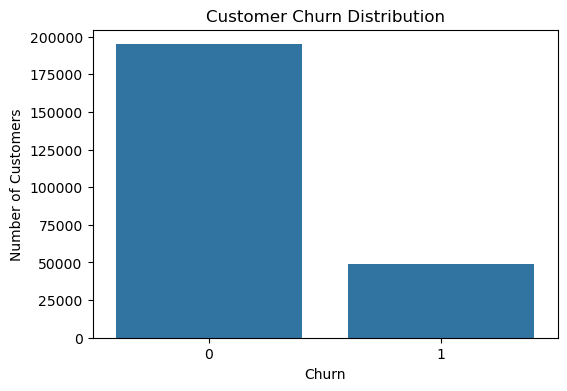

In [168]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

### Churn Distribution by Telecom Partner

In [169]:
pd.crosstab(df['telecom_partner'], df['churn'])

churn,0,1
telecom_partner,,
Airtel,48724,12181
BSNL,48644,12079
Reliance Jio,49023,12100
Vodafone,48451,12351


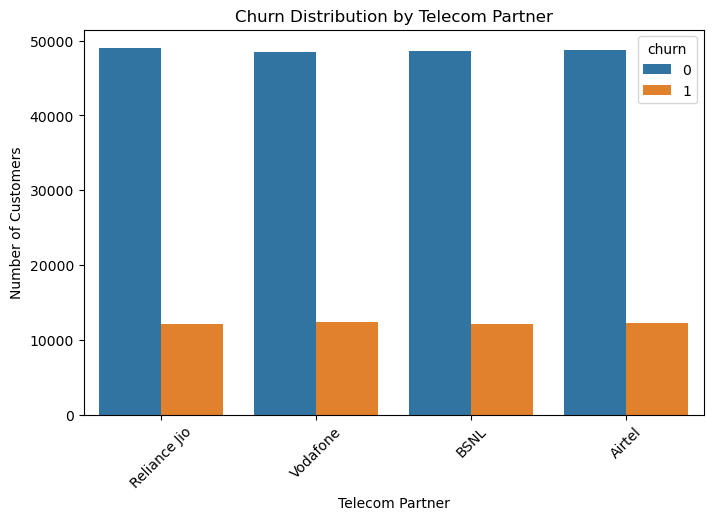

In [170]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='telecom_partner', hue='churn')
plt.title('Churn Distribution by Telecom Partner')
plt.xlabel('Telecom Partner')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

### Churn Distribution by Gender

In [171]:
pd.crosstab(df['gender'], df['churn'])

churn,0,1
gender,,
F,78003,19573
M,116839,29138


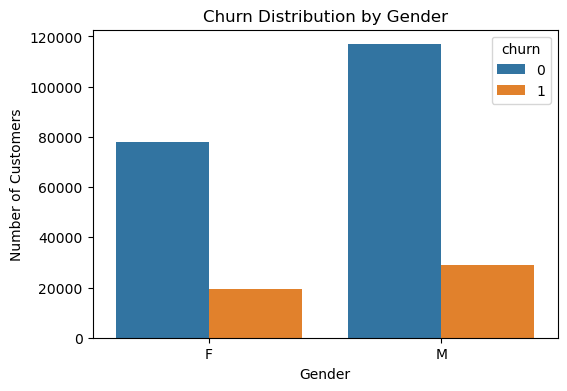

In [172]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='churn')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Churn Distribution by Age

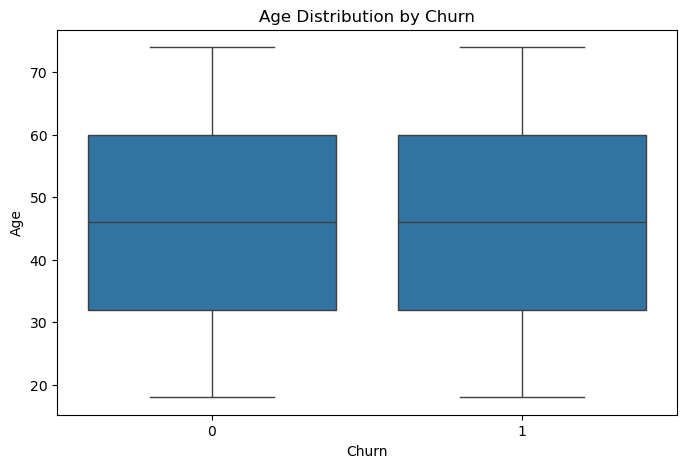

In [173]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='age')
plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Age')
plt.show()

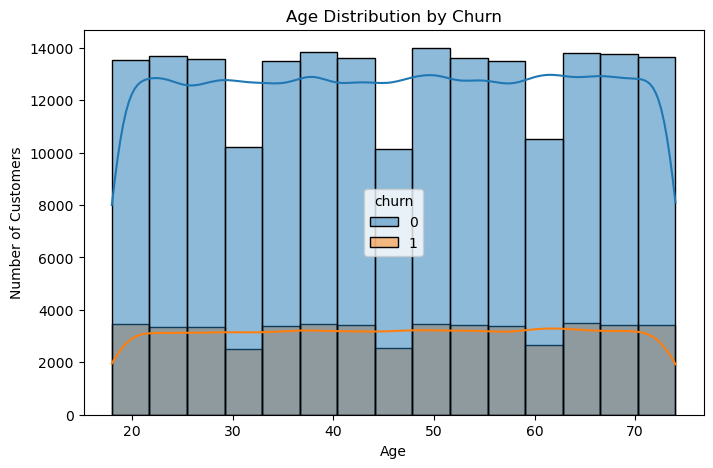

In [174]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='churn', bins=15, kde=True)
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

### Churn Distribution by Customer Dependents

In [175]:
pd.crosstab(df['num_dependents'], df['churn'])

churn,0,1
num_dependents,,
0,39006,9921
1,38982,9719
2,38955,9650
3,39014,9680
4,38885,9741


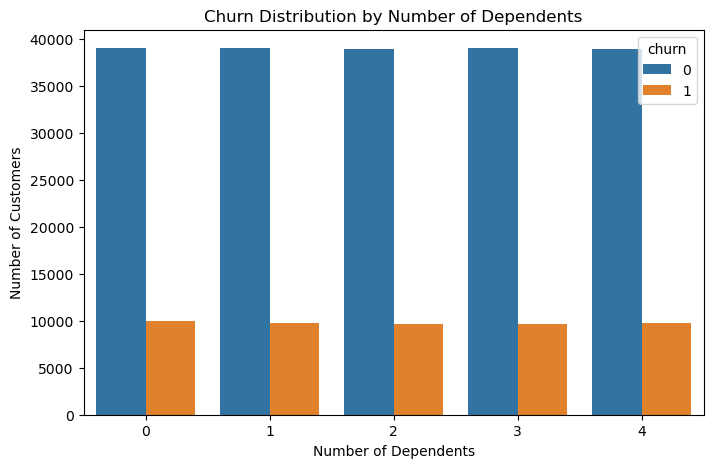

In [176]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='num_dependents', hue='churn')
plt.title('Churn Distribution by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Customers')
plt.show()

### Churn Distribution by Estimated Salary

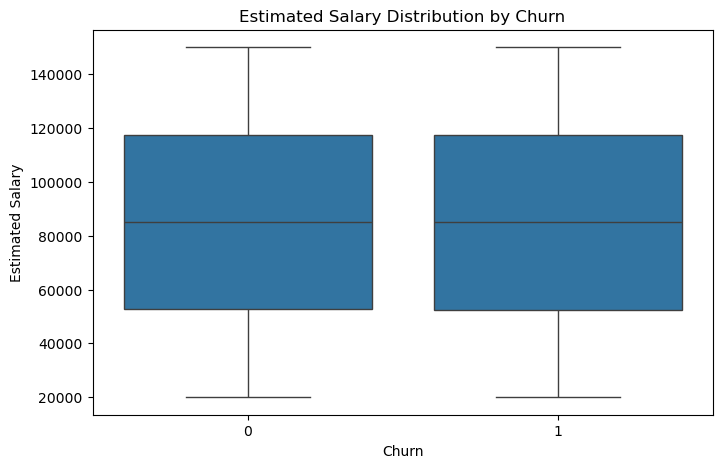

In [177]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='estimated_salary')
plt.title('Estimated Salary Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Estimated Salary')
plt.show()

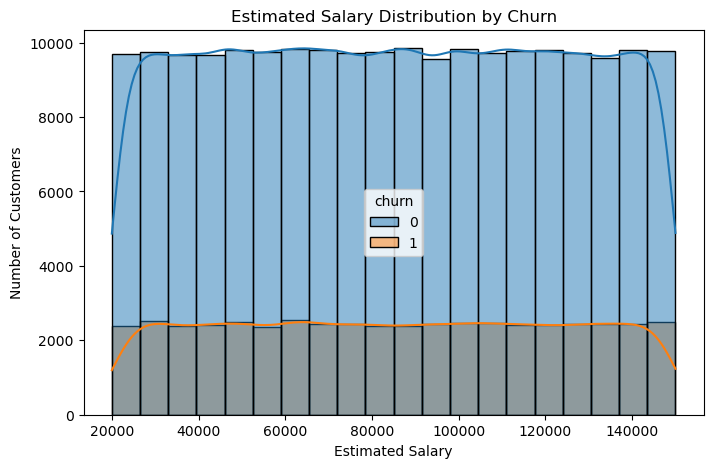

In [178]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='estimated_salary', hue='churn', bins=20, kde=True)
plt.title('Estimated Salary Distribution by Churn')
plt.xlabel('Estimated Salary')
plt.ylabel('Number of Customers')
plt.show()

### Churn Distribution by Calls Made

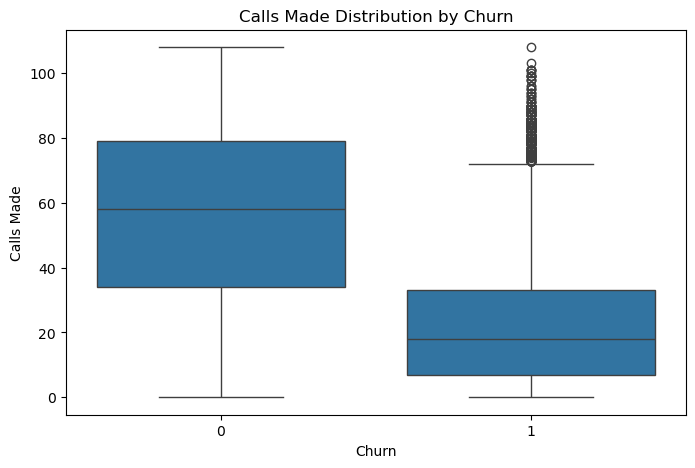

In [179]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='calls_made')
plt.title('Calls Made Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Calls Made')
plt.show()

**Insight:** Customers with lower call activity show a higher tendency toward churn in the modeling dataset. This suggests that customer engagement through voice calls may be an important indicator of churn risk.

### Churn Distribution by SMS Sent

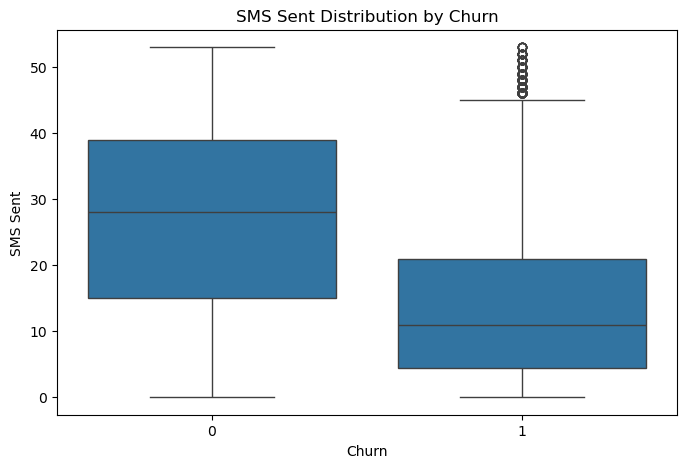

In [180]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='sms_sent')
plt.title('SMS Sent Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('SMS Sent')
plt.show()

**Insight:** Lower SMS activity is associated with higher churn in the modeling dataset, indicating that reduced customer engagement may be related to churn risk.

### Churn Distribution by Data Usage

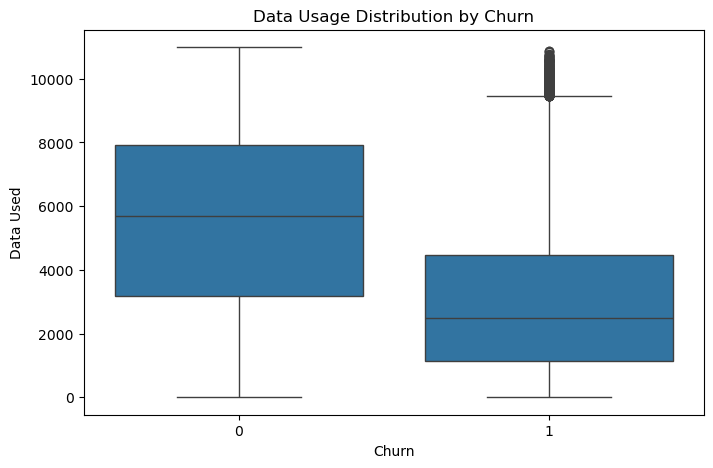

In [181]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='data_used')
plt.title('Data Usage Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Data Used')
plt.show()

**Insight:** Customers with lower data usage show higher churn tendency in the modeling dataset. Data consumption therefore represents an important customer engagement indicator.

### Correlation Analysis

In [182]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
customer_id,1.000000,-0.001100,-0.002416,-0.000464,0.000194,0.003456,0.000180,0.000648,-0.004181
age,-0.001100,1.000000,0.000586,0.001462,-0.003103,-0.001369,-0.002828,0.000773,0.000861
pincode,-0.002416,0.000586,1.000000,-0.002771,0.002099,0.001696,0.001388,0.001280,-0.001880
num_dependents,-0.000464,0.001462,-0.002771,1.000000,0.002157,0.000286,0.002144,0.003093,-0.002011
estimated_salary,0.000194,-0.003103,0.002099,0.002157,1.000000,-0.000138,0.002565,-0.003339,0.000607
calls_made,0.003456,-0.001369,0.001696,0.000286,-0.000138,1.000000,0.000127,0.001168,-0.462785
sms_sent,0.000180,-0.002828,0.001388,0.002144,0.002565,0.000127,1.000000,-0.002898,-0.345502
data_used,0.000648,0.000773,0.001280,0.003093,-0.003339,0.001168,-0.002898,1.000000,-0.343631
churn,-0.004181,0.000861,-0.001880,-0.002011,0.000607,-0.462785,-0.345502,-0.343631,1.000000


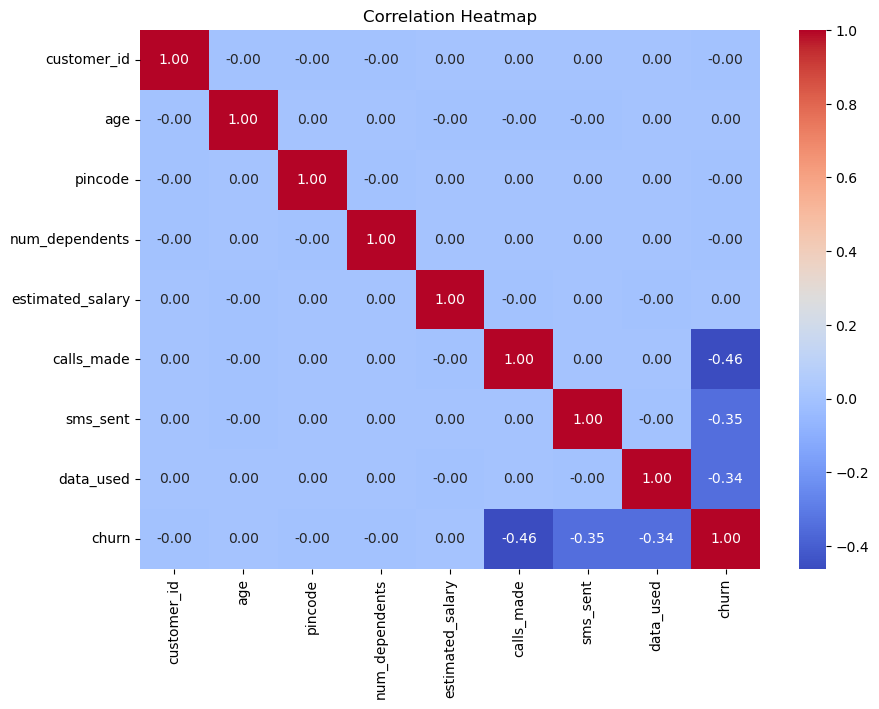

In [183]:
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Insight:** The strongest numerical relationships with churn are observed in the customer engagement variables. These relationships are consistent with the behavioral churn definition used for this modeling exercise. Demographic variables such as age and salary show comparatively weaker relationships with churn.

## Data Preprocessing

In [184]:
df.dtypes

customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

In [185]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique())


telecom_partner:
4

gender:
2

state:
28

city:
6

date_of_registration:
1220


In [186]:
df['churn'].value_counts()

churn
0    194842
1     48711
Name: count, dtype: int64

In [187]:
df.shape

(243553, 14)

## Feature Engineering and Preprocessing

In [188]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique())


telecom_partner:
4

gender:
2

state:
28

city:
6

date_of_registration:
1220


### Date Feature Engineering

In [189]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

In [190]:
df['registration_year'] = df['date_of_registration'].dt.year
df['registration_month'] = df['date_of_registration'].dt.month
df['registration_day'] = df['date_of_registration'].dt.day

In [191]:
df[['date_of_registration', 'registration_year', 'registration_month', 'registration_day']].head()

,date_of_registration,registration_year,registration_month,registration_day
0,2020-01-01,2020,1,1
1,2020-01-01,2020,1,1
2,2020-01-01,2020,1,1
3,2020-01-01,2020,1,1
4,2020-01-01,2020,1,1


In [192]:
df[['registration_year', 'registration_month', 'registration_day']].describe()

,registration_year,registration_month,registration_day
count,243553.000000,243553.000000,243553.000000
mean,2021.200983,6.122257,15.678189
std,0.981270,3.501190,8.806972
min,2020.000000,1.000000,1.000000
25%,2020.000000,3.000000,8.000000
50%,2021.000000,6.000000,16.000000
75%,2022.000000,9.000000,23.000000
max,2023.000000,12.000000,31.000000


In [193]:
df.columns.tolist()

['customer_id',
 'telecom_partner',
 'gender',
 'age',
 'state',
 'city',
 'pincode',
 'date_of_registration',
 'num_dependents',
 'estimated_salary',
 'calls_made',
 'sms_sent',
 'data_used',
 'churn',
 'registration_year',
 'registration_month',
 'registration_day']

### Encoding Categorical Features

In [194]:
categorical_columns = ['telecom_partner', 'gender', 'state', 'city']

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [195]:
df.shape

(243553, 49)

In [196]:
df.dtypes

customer_id                              int64
age                                      int64
pincode                                  int64
date_of_registration            datetime64[ns]
num_dependents                           int64
estimated_salary                         int64
calls_made                               int64
sms_sent                                 int64
data_used                                int64
churn                                    int64
registration_year                        int32
registration_month                       int32
registration_day                         int32
telecom_partner_BSNL                     int64
telecom_partner_Reliance Jio             int64
telecom_partner_Vodafone                 int64
gender_M                                 int64
state_Arunachal Pradesh                  int64
state_Assam                              int64
state_Bihar                              int64
state_Chhattisgarh                       int64
state_Goa    

In [197]:
df['pincode'].nunique()

213442

In [198]:
df.drop(columns=['pincode'], inplace=True)

In [199]:
df.shape

(243553, 48)

### Preparing Features and Target

In [200]:
X = df.drop(columns=['churn'])
y = df['churn']

In [201]:
X.shape, y.shape

((243553, 47), (243553,))

### Train-Test Split

In [202]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [203]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((194842, 47), (48711, 47), (194842,), (48711,))

### Feature Scaling

In [205]:
from sklearn.preprocessing import StandardScaler

# Keep only numeric features for scaling
X_train_numeric = X_train.select_dtypes(include='number')
X_test_numeric = X_test.select_dtypes(include='number')

# Make sure both datasets have exactly the same columns
X_test_numeric = X_test_numeric[X_train_numeric.columns]

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (194842, 46)
X_test_scaled shape: (48711, 46)


In [155]:
X_train_scaled.shape, X_test_scaled.shape

((194842, 45), (48711, 45))

## Model Building and Evaluation

### Logistic Regression

In [206]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Logistic Regression Results
Accuracy: 0.9357024080803104
Precision: 0.8562958171625701
Recall: 0.8153356600287416
F1 Score: 0.8353139131349248
ROC-AUC: 0.9797655595347416

Confusion Matrix:
[[37636  1333]
 [ 1799  7943]]


### Random Forest Classifier

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9254993738580608
Precision: 0.9163601689143168
Recall: 0.690515294600698
F1 Score: 0.7875665866651057
ROC-AUC: 0.9744456820451469

Confusion Matrix:
[[38355   614]
 [ 3015  6727]]


In [209]:
print("Actual Churn:")
print(y_test.value_counts())

print("\nPredicted Churn:")
print(pd.Series(y_pred_rf).value_counts())

Actual Churn:
churn
0    38969
1     9742
Name: count, dtype: int64

Predicted Churn:
0    41370
1     7341
Name: count, dtype: int64


In [210]:
feature_importance = pd.DataFrame({
    'Feature': X_train_numeric.columns,
    'Coefficient': logistic_model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
4,calls_made,-4.177574,4.177574
5,sms_sent,-3.148706,3.148706
6,data_used,-3.114113,3.114113
34,state_Sikkim,0.030121,0.030121
28,state_Meghalaya,0.025767,0.025767
32,state_Punjab,0.023998,0.023998
21,state_Himachal Pradesh,0.018589,0.018589
29,state_Mizoram,-0.016700,0.016700
27,state_Manipur,-0.016528,0.016528
8,registration_month,-0.013037,0.013037


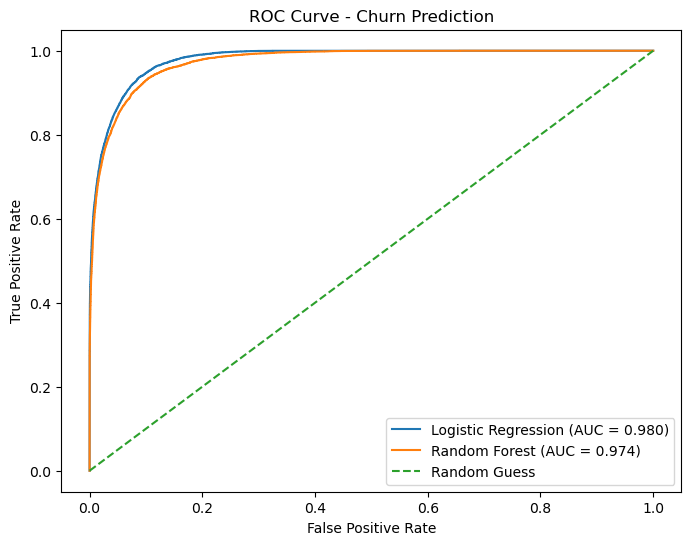

In [211]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend()
plt.show()

### Random Forest Hyperparameter Tuning

GridSearchCV is used to systematically evaluate different Random Forest hyperparameter combinations using cross-validation. The combination that achieves the best F1-score is selected as the tuned model.

In [221]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.8132339989900084


In [222]:
# Best tuned Random Forest model
best_rf_model = rf_grid.best_estimator_

# Predictions
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Tuned Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned Random Forest Results
Accuracy: 0.9316170885426289
Precision: 0.8918225155848918
Recall: 0.7489221925682611
F1 Score: 0.8141494169502873
ROC-AUC: 0.976622727963748

Confusion Matrix:
[[38084   885]
 [ 2446  7296]]


### XGBoost Classifier

XGBoost is evaluated as an additional tree-based classification algorithm. Its performance is compared with Logistic Regression and Random Forest using multiple classification metrics.

In [219]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.9352097062265197
Precision: 0.8537056928034371
Recall: 0.8158489016629029
F1 Score: 0.8343480999370145
ROC-AUC: 0.9793246766867456

Confusion Matrix:
[[37607  1362]
 [ 1794  7948]]


## Model Comparison

The performance of Logistic Regression, Random Forest, tuned Random Forest, and XGBoost is compared using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a comprehensive evaluation of classification performance and the ability to identify customers likely to churn.

In [223]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9357,0.8563,0.8153,0.8353,0.9798
1,Random Forest,0.9255,0.9164,0.6905,0.7876,0.9744
2,Tuned Random Forest,0.9316,0.8918,0.7489,0.8141,0.9766
3,XGBoost,0.9352,0.8537,0.8158,0.8343,0.9793


## Model Selection

Four classification approaches were evaluated: Logistic Regression, Random Forest, tuned Random Forest, and XGBoost.

Logistic Regression achieved the best overall balance of performance, with an accuracy of 93.57%, F1-score of 83.53%, and ROC-AUC of 97.98%. XGBoost produced very similar results, with an accuracy of 93.52%, F1-score of 83.43%, and ROC-AUC of 97.93%.

Hyperparameter tuning improved the Random Forest model, increasing its F1-score from 78.76% to 81.41% and recall from 69.05% to 74.89%.

Based on the overall balance of accuracy, recall, F1-score, and ROC-AUC, Logistic Regression was selected as the final model.

## Final Model — Confusion Matrix

The confusion matrix shows how well the selected Logistic Regression model distinguishes between customers who churn and those who do not churn.

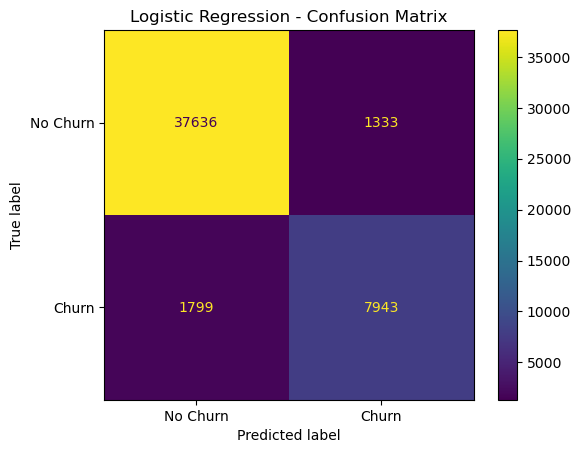

In [213]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Saving the Final Model

The selected Logistic Regression model and the feature scaler are saved using Joblib. Saving both components allows the trained model and the same preprocessing procedure to be reused for future predictions.

In [224]:
import joblib

# Save the selected Logistic Regression model
joblib.dump(logistic_model, "telecom_churn_logistic_model.pkl")

# Save the scaler used during preprocessing
joblib.dump(scaler, "telecom_churn_scaler.pkl")

print("Final model and scaler saved successfully.")

Final model and scaler saved successfully.


## Business Interpretation

The final model can be used to identify customers who have a higher likelihood of churn based on their available demographic and engagement characteristics.

In a real-world telecom environment, customers identified as high-risk could be prioritized for retention activities such as personalized offers, proactive customer support, service-quality improvements, or targeted communication campaigns.

The model can therefore support a proactive retention strategy by helping businesses focus their resources on customers who are more likely to leave.

## Limitations and Future Improvements

### Limitations

- The original churn label showed very weak relationships with the available customer features.
- A behavioral churn target was therefore constructed using customer engagement indicators such as calls made, SMS sent, and data usage for this machine learning exercise.
- Consequently, the reported model performance should be interpreted as an evaluation of the modeling workflow rather than as production-level performance on real customer churn outcomes.
- The current dataset does not include several potentially important real-world churn indicators such as customer tenure, contract type, billing history, complaints, service issues, and customer support interactions.

### Future Improvements

- Use historical, independently recorded customer churn outcomes from a real telecom dataset.
- Include additional behavioral and transactional features such as tenure, monthly charges, contract type, payment history, complaints, and service interactions.
- Perform probability calibration and threshold optimization based on business retention costs.
- Experiment with additional models and advanced ensemble techniques.
- Deploy the final model through an API or interactive dashboard for real-time churn-risk prediction.

## Conclusion

This project developed an end-to-end customer churn classification workflow using Python and machine learning.

The project covered data loading, data quality analysis, exploratory data analysis, feature engineering, categorical encoding, feature scaling, model development, hyperparameter tuning, and comprehensive model evaluation.

Four classification approaches were evaluated: Logistic Regression, Random Forest, tuned Random Forest, and XGBoost. Logistic Regression achieved the strongest overall performance, with 93.57% accuracy, 83.53% F1-score, and 97.98% ROC-AUC, and was therefore selected as the final model.

Hyperparameter tuning also demonstrated an improvement in the Random Forest model, particularly in recall and F1-score.

From a business perspective, the modeling workflow demonstrates how customer engagement information can be used to identify potential churn-risk customers and support targeted retention strategies.

However, because the churn target used in this exercise was constructed from behavioral engagement indicators, the results should be considered a demonstration of the machine learning methodology rather than production-level churn prediction. A real-world implementation would require independently observed historical churn outcomes and richer customer information.